In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch import nn
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# CHANG THIS !!!!!
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_4/checkpoints/epoch=870-total_loss=24.99072456.ckpt"

In [22]:
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

In [23]:
pde_model = model_class.load_from_checkpoint(ckpt_path)

# load data

In [5]:
# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 8
n_grid = 50


In [6]:
# the DS
DS_t7 = reader.AllTimepoint_MeshGrid(AnnData=adata, 
                                resampling_indensity=0.3, 
                                resampling_rate=0,
                                n_timepoint = n_timepoint,
                                timepoint_key = 'time',
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                n_grid=n_grid,  
                                nearby_cellstate=3, 
                                collocation_points=300, 
                                log_transform=False,
                                norm_time = False,
                                n_repeat=2
                              )


In [7]:
xi = DS_t7[0]

In [8]:
[len(tp) for tp in xi]

[2, 8, 2]

In [9]:
# adata
t7_ad = DS_t7.adata.copy()
u_b = DS_t7.u_b
cellstate = DS_t7.s

In [10]:
u_b.shape

(8, 2500)

In [11]:
cellstate.shape

(2500, 2)

# Simulation

In [12]:
from torch.utils.data import DataLoader

In [13]:
init_u_b = DS_t7.u_b
batch_size = 50
train_DL = DataLoader(DS_t7, batch_size=batch_size, num_workers=1, shuffle=False)
timepoints = timepoints[:n_timepoint]
print(timepoints)

[12.5 13.5 14.5 15.5 16.5 17.5 18.5 19.5]


In [14]:
len(DS_t7)

2500

In [15]:
i = 10

s_bund_ls = []
s_neighbor_ls = []
t_b_ls = []
u_b_ls = []
u_neighbor_ls = []

for j in range(min(10, len(DS_t7)-i)):
    (s_bund,s_neighbor), t_b, (u_b, u_neighbor) = DS_t7[i]
    s_bund_ls.append(s_bund)
    s_neighbor_ls.append(s_neighbor)
    t_b_ls.append(t_b)
    u_b_ls.append(u_b)
    u_neighbor_ls.append(u_neighbor)

In [16]:
# with torch.no_grad():
for train_batch in train_DL:
    (s_bund,s_neighbor), t_b, (u_b, u_neighbor) = train_batch

In [75]:
# CHANG THIS !!!!!
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_1/checkpoints/epoch=194-total_loss=9.40586662.ckpt"
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")
pde_model = model_class.load_from_checkpoint(ckpt_path)

pde_model = pde_model.to("cuda:5")

In [76]:

# prediction
t_b = DS_t7.t_b[:,0]
t_list = t_b / 5
t_list
## predict u with ode integrat


u_int_all = [init_u_b[0]]
chunk_size= 500

it = 0
for it in tqdm(range(len(timepoints)-1)):
    t0 = t_list[it]
    t1 = t_list[it+1]
    u_t_ls = []

    with torch.no_grad():
        for train_batch in train_DL:

            (s_bund,s_neighbor), t_b, (u_b, u_neighbor) = train_batch
            # s0 = cellstate.to(device)

            ut0 = u_b[:,it]
            utp1 = u_b[:,it+1]
            u_neighbor_t0 = u_neighbor[:, it]


            step_size = np.around((t1 - t0)/15, decimals=1).item() 
            step_size = step_size if step_size > 0 else 0.05
            step_size = min(step_size, 0.4)

            init_condition = ( 
                            s_neighbor.to(device), 
                            u_neighbor_t0.to(device))
            
            _, u_neighbor_int = odeint(
                        pde_model.ode_func,
                        init_condition,
                        torch.tensor([t0,t1]).float().to(device),
                        atol=1e-8,
                        rtol=1e-8,
                        method='midpoint',
                        options = {'step_size': step_size}
                    )

            torch.cuda.empty_cache()
            u_int = nn.functional.relu(u_neighbor_int[-1])
            u_int = u_int[:,1,1]
            u_t_ls.append(u_int.detach().cpu().numpy())
            torch.cuda.empty_cache()

        u_int = np.concatenate(u_t_ls)
        
        u_int_all.append(u_int)

u_int.shape, len(u_int_all)
[u.shape for u in u_int_all]
u_int_all = np.stack(u_int_all)
u_int_all.shape

flat_u = init_u_b.reshape(-1,50,50).sum(axis=1)
flat_u_int = u_int_all.reshape(-1,50,50).sum(axis=1)

  0%|          | 0/7 [00:00<?, ?it/s]

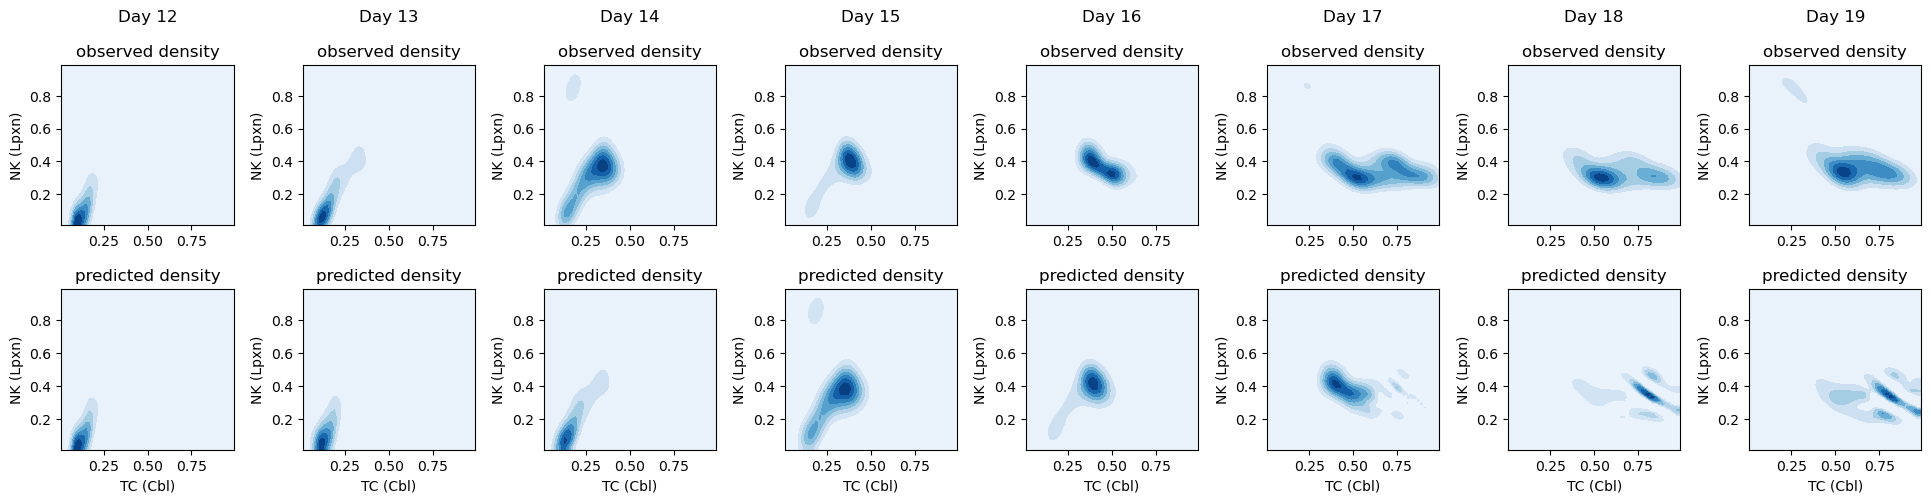

In [77]:
PINN.pl.meshgrid_density_by_time(init_u_b, u_int_all, DS_t7, 'TC (Cbl)', 'NK (Lpxn)');                                                                  

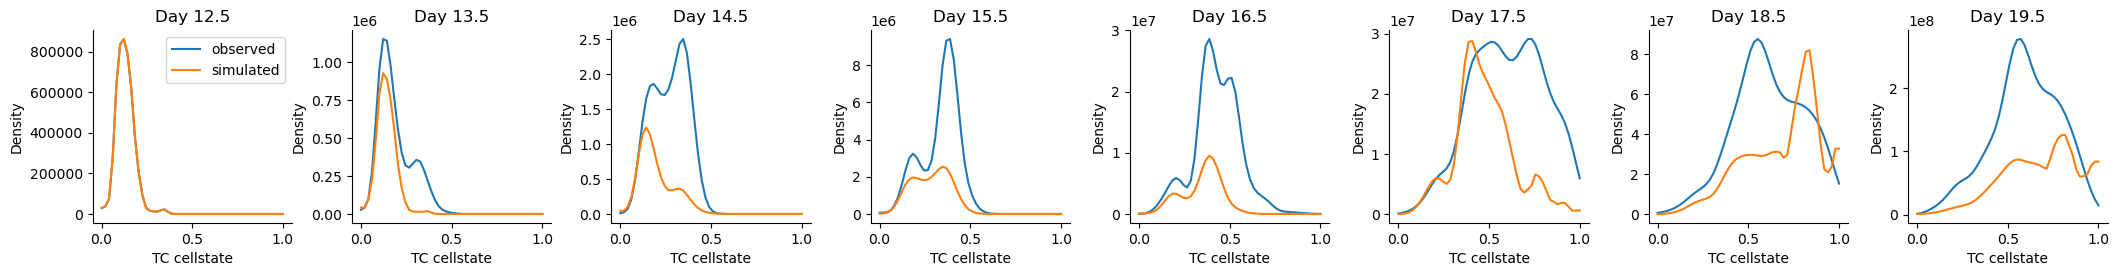

In [78]:
fig, axs = plt.subplots(1, len(DS_t7.T_b), figsize=(26, 2.5), gridspec_kw={'wspace':0.3})
for i,t in enumerate(DS_t7.T_b):
    axs[i].plot(np.linspace(0,1,50),flat_u[i], label='observed')
    axs[i].plot(np.linspace(0,1,50),flat_u_int[i],  label='simulated')
    
    axs[i].set_title("Day %s"%t)
    axs[i].set_xlabel("TC cellstate")
    axs[i].set_ylabel("Density")

    sns.despine(ax=axs[i])
axs[0].legend()

In [90]:
device = pde_model.device
s = torch.from_numpy(cellstate).to(device).float()

g = []
v = []
D = []

for i,t in enumerate(DS_t7.T_b):

    with torch.no_grad():
        t = torch.from_numpy(DS_t7.t_b[i]).to(device)
        
        g.append(pde_model.g(s,t).cpu().numpy())
        v.append(pde_model.v(s,t).cpu().numpy())
        D.append(pde_model.D(s,t).cpu().numpy())


In [ ]:
len(g)

# visualized other versions

## version 1 weight intensity = 0.5
```python
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_1/checkpoints/epoch=194-total_loss=9.40586662.ckpt"
```

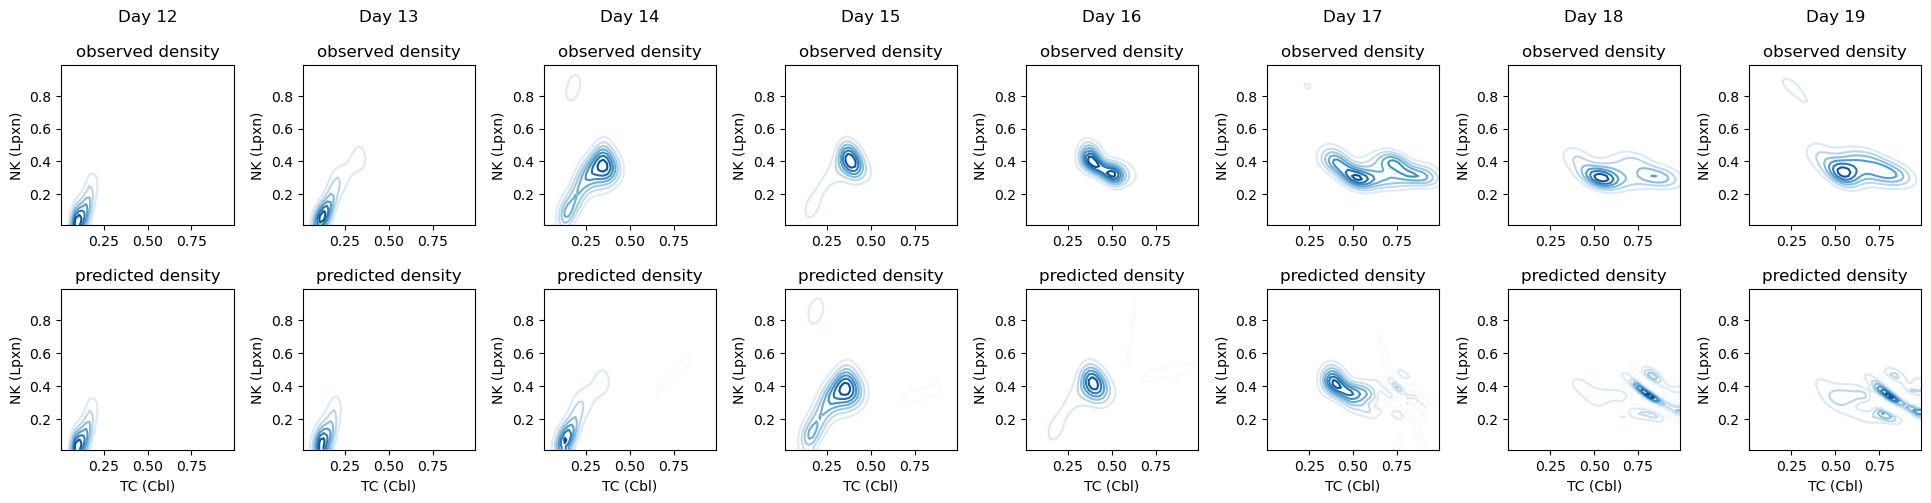

In [19]:
PINN.pl.meshgrid_density_by_time(init_u_b, u_int_all, DS_t7, 'TC (Cbl)', 'NK (Lpxn)');

## version 2
```python
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_2/checkpoints/epoch=459-total_loss=23.65041161.ckpt"
```

In [48]:
from importlib import reload
reload(PINN)

<module 'PINN' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/__init__.py'>

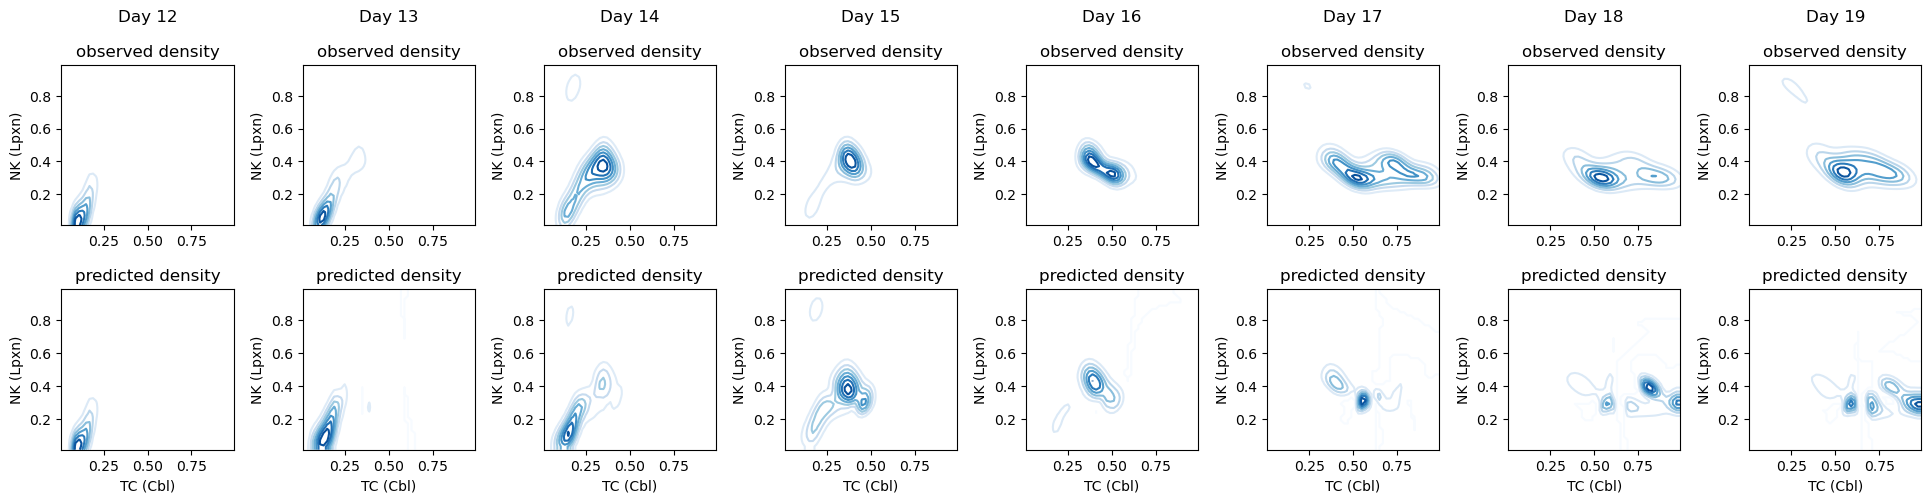

In [ ]:
PINN.pl.meshgrid_density_by_time(init_u_b, u_int_all, DS_t7, 'TC (Cbl)', 'NK (Lpxn)');                                                                  

## version 3 CyclicLR --lr 3e-4 --weight_intensity 2
```python
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_3/checkpoints/epoch=894-total_loss=25.87684822.ckpt"
```

## version 4
```python
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_4/checkpoints/epoch=956-total_loss=21.13482666.ckpt"
```

## version 5 CyclicLR --lr 3e-5 --weight_intensity 3 
```python
ckpt_path = "logs/David_cellstates-Cbl_Lpxn_scaled_multiBnch/pde_neighborloss/lightning_logs/version_5/checkpoints/epoch=48-total_loss=33.33790970.ckpt"
```

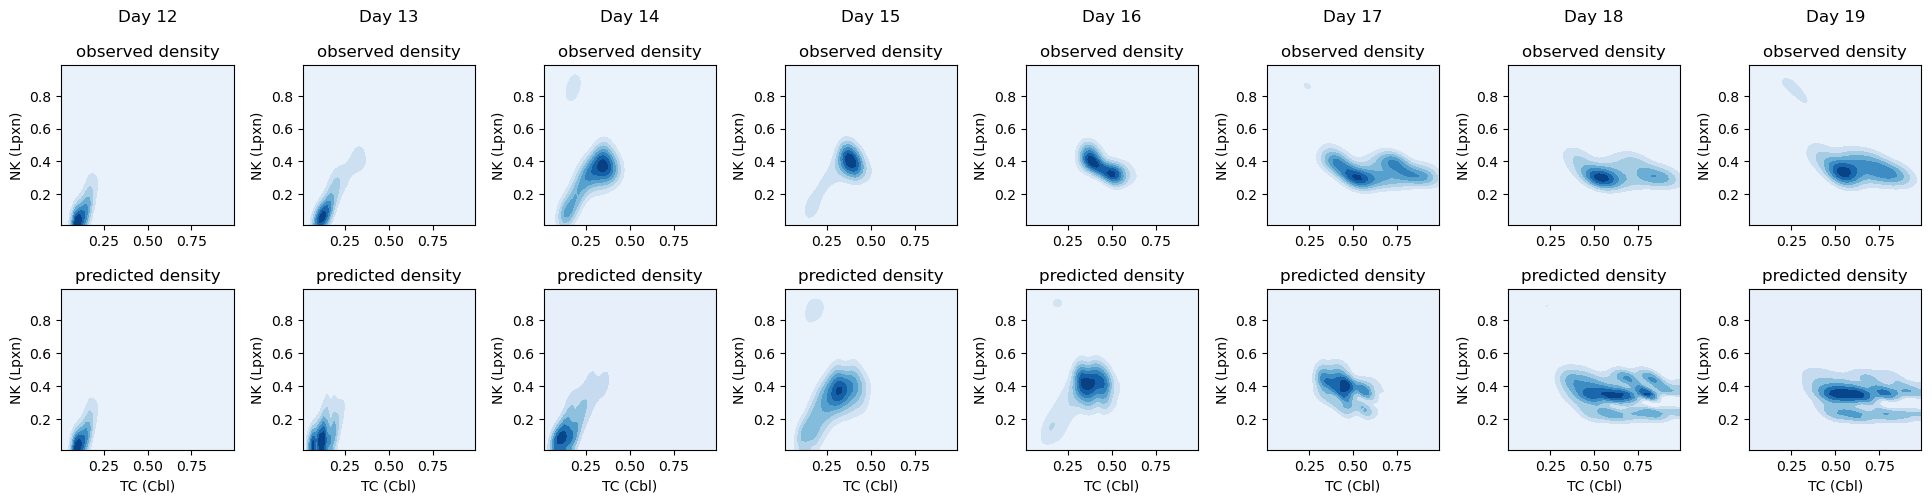

In [ ]:
PINN.pl.meshgrid_density_by_time(init_u_b, u_int_all, DS_t7, 'TC (Cbl)', 'NK (Lpxn)');                                                                  